In [25]:
import os
print(" 현재 경로:", os.getcwd())
# 1. 파일이 있는 실제 경로를 복사해서 넣어주세요

# 2. 해당 경로로 작업 디렉토리 변경
os.chdir("/mnt/batch/tasks/shared/LS_root/mounts/clusters/student0208/code/Users/student02_08/Jan27_1_MachineLearning")

# 3. 변경된 경로 확인
print("변경된 현재 경로:", os.getcwd())



 현재 경로: /mnt/batch/tasks/shared/LS_root/mounts/clusters/student0208/code/Users/student02_08/Jan27_1_MachineLearning
변경된 현재 경로: /mnt/batch/tasks/shared/LS_root/mounts/clusters/student0208/code/Users/student02_08/Jan27_1_MachineLearning


In [ ]:
# subway.csv
# 역별로 탄것평균/내린것 평균
# 3그룹(붐빔,평균,파리)
 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./subway.csv',names=["년","월","일","호선","역","타","내리"],encoding="utf-8")

print(df)


            년   월   일   호선     역      타     내리
0        2015   1   1  1호선   서울역  47071  40197
1        2015   1   1  1호선    시청  11016   8943
2        2015   1   1  1호선    종각  22084  17648
3        2015   1   1  1호선  종로3가  17917  15817
4        2015   1   1  1호선  종로5가   9789   9216
...       ...  ..  ..  ...   ...    ...    ...
2143338  2024  12  31  중앙선    오빈    275    289
2143339  2024  12  31  중앙선    양평   3110   3426
2143340  2024  12  31  중앙선    원덕    307    294
2143341  2024  12  31  중앙선    용문   1751   1947
2143342  2024  12  31  중앙선    지평     52     76

[2143343 rows x 7 columns]


In [43]:
from sklearn.cluster import KMeans

 
avg = df.groupby('역')[['타', '내리']].mean()

km = KMeans(3) 
avg['group_num'] = km.fit_predict(avg)
avg["그룹"] = avg['group_num'].replace([0, 1, 2], ['파리', '평범', '붐빔'])



avg


,타,내리,group_num,그룹
역,,,,
4.19민주묘지,2994.794623,2860.110530,0,파리
가능,6761.949630,6417.983575,0,파리
가락시장,7917.660964,8260.135368,0,파리
가산디지털단지,26457.021489,27727.780044,1,평범
가양,19658.998084,19004.231864,2,붐빔
...,...,...,...,...
회룡,12398.163154,12050.954010,2,붐빔
회현,29231.298780,31101.428354,1,평범
회현(남대문시장),25301.806473,26577.192192,1,평범


<Axes: xlabel='타', ylabel='내리'>

/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/anaconda/envs/jupyter_env/lib/python3.10/

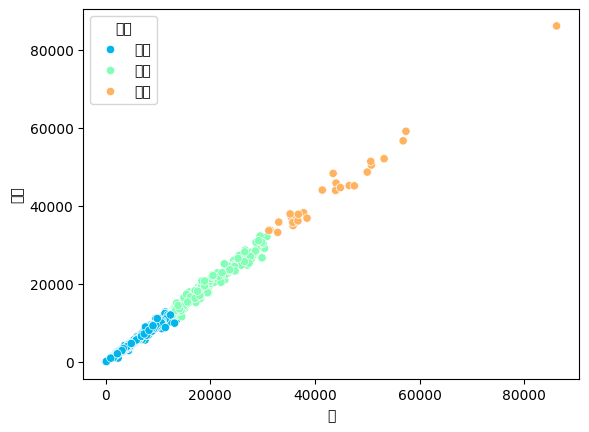

In [42]:
sns.scatterplot(data=avg, x="타", y="내리", hue="그룹", palette="rainbow")